## Milestone 2 (Weeks 5 - )

In [ ]:
# Week 5 — SVR/SVC end-to-end (feature build + models)
import pandas as pd, numpy as np
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.svm import SVR, SVC

# --------------------------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------------------------
EMISSIONS = "emissions_medium_granularity.csv"
PRICES    = "all_fuels_data.csv"
PIPELINE  = "Oil_Pipeline.csv"
OUT_CSV   = "week5_features.csv"

# --------------------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------------------
def coalesce(df: pd.DataFrame, candidates):
    """Return the first column that matches any candidate (exact or 'contains')."""
    # exact
    for cand in candidates:
        for col in df.columns:
            if col.lower() == cand.lower():
                return col
    # contains
    for cand in candidates:
        for col in df.columns:
            if cand.lower() in col.lower():
                return col
    return None

def norm_commodity(s: str) -> str:
    """Lightweight normalization across tables."""
    s = str(s).strip().lower()
    s = s.replace("&", "and").replace("  ", " ")
    s = s.replace("natural gas", "gas")
    s = s.replace("oil & ngl", "oil and ngl").replace("oil & ngls", "oil and ngl")
    s = s.replace("ngl", "ngl")   # placeholder (keep)
    return s

# --------------------------------------------------------------------------------------
# Load
# --------------------------------------------------------------------------------------
em = pd.read_csv(EMISSIONS)
pr = pd.read_csv(PRICES)
op = pd.read_csv(PIPELINE)

# --------------------------------------------------------------------------------------
# Identify columns
# --------------------------------------------------------------------------------------
year_col = coalesce(em, ["year"])
firm_col = coalesce(em, ["parent_entity","company","firm","operator","parent","entity"])
ptype_col = coalesce(em, ["parent_type","type"])
comm_em   = coalesce(em, ["commodity","fuel","product"])
prod_col  = coalesce(em, ["production_value","production","output"])
emis_col  = coalesce(em, ["total_emissions_MtCO2e","emissions","emissions_mtco2e","total_emissions"])
assert year_col and comm_em and emis_col, "Missing core emissions columns."

date_pr  = coalesce(pr, ["date","tradedate","day"])
comm_pr  = coalesce(pr, ["commodity","fuel","product"])
close_pr = coalesce(pr, ["close","settle","price","closing_price"])
assert date_pr and comm_pr and close_pr, "Missing price columns."

date_op = coalesce(op, ["date","accident date","incident date","occurred on","reported date"])
if date_op is None:
    # pick the first date-like col if names vary
    date_candidates = [c for c in op.columns if "date" in c.lower()]
    date_op = date_candidates[0] if date_candidates else None
assert date_op, "Pipeline incidents file must have a date/incident date column."

# --------------------------------------------------------------------------------------
# Emissions (2010–2022) + commodity normalization
# --------------------------------------------------------------------------------------
em2 = em.copy()
em2[year_col] = pd.to_numeric(em2[year_col], errors="coerce")
em2 = em2.dropna(subset=[year_col, emis_col]).copy()
em2 = em2.loc[em2[year_col].between(2010, 2022)].copy()
em2[year_col] = em2[year_col].astype(int)

# normalize commodity in emissions
em2["_comm_norm"] = em2[comm_em].map(norm_commodity)

# --------------------------------------------------------------------------------------
# Prices → annual average close by (year, commodity_norm) with alias mapping
# --------------------------------------------------------------------------------------
pr2 = pr.copy()
pr2[date_pr] = pd.to_datetime(pr2[date_pr], errors="coerce")
pr2["year"] = pr2[date_pr].dt.year
pr2 = pr2.dropna(subset=["year", comm_pr, close_pr]).copy()
pr2["year"] = pr2["year"].astype(int)

# normalize commodity in prices
pr2["_comm_norm"] = pr2[comm_pr].map(norm_commodity)

ALIAS = {
    "oil and ngl": "crude oil",  # maps emissions "Oil & NGL" → price series "crude oil"
    "gas": "gas",
}
em2["_comm_norm"] = em2["_comm_norm"].replace(ALIAS)
pr2["_comm_norm"] = pr2["_comm_norm"].replace(ALIAS)


annual_price = (pr2.groupby(["year","_comm_norm"])[close_pr]
                  .mean().rename("annual_price").reset_index())

# --------------------------------------------------------------------------------------
# Pipeline incidents → yearly aggregates
# --------------------------------------------------------------------------------------
op2 = op.copy()
op2[date_op] = pd.to_datetime(op2[date_op], errors="coerce")
op2["year"] = op2[date_op].dt.year
op2 = op2.dropna(subset=["year"]).copy()
op2["year"] = op2["year"].astype(int)

inc_year = op2.groupby("year").size().rename("incidents_count").reset_index()
cost_cols = [c for c in op.columns if ("cost" in c.lower()) or ("damage" in c.lower())]
if cost_cols:
    op2["all_costs_sum"] = op2[cost_cols].select_dtypes(include=[np.number]).sum(axis=1)
    costs_year = op2.groupby("year")["all_costs_sum"].sum().reset_index()
else:
    costs_year = pd.DataFrame({"year": inc_year["year"], "all_costs_sum": 0.0})

inc_agg = inc_year.merge(costs_year, on="year", how="outer").fillna(0)

# --------------------------------------------------------------------------------------
# Merge → company-year features
# --------------------------------------------------------------------------------------
feat = (em2.merge(annual_price, left_on=[year_col, "_comm_norm"], right_on=["year","_comm_norm"], how="left")
            .merge(inc_agg, left_on=year_col, right_on="year", how="left", suffixes=("","_inc")))

# Tidy year columns
if "year_x" in feat.columns: feat = feat.rename(columns={"year_x":"year"})
for c in ("year_y","year_inc"):
    if c in feat.columns: feat.drop(columns=c, inplace=True)

# Feature transforms
feat["y_reg_log_emissions"] = np.log1p(pd.to_numeric(feat[emis_col], errors="coerce").fillna(0))
feat["log1p_production"]    = np.log1p(pd.to_numeric(feat.get(prod_col, 0), errors="coerce").fillna(0))
feat["log1p_annual_price"]  = np.log1p(pd.to_numeric(feat.get("annual_price", 0), errors="coerce").fillna(0))
feat["log1p_incidents"]     = np.log1p(pd.to_numeric(feat.get("incidents_count", 0), errors="coerce").fillna(0))
feat["log1p_incident_costs"]= np.log1p(pd.to_numeric(feat.get("all_costs_sum", 0), errors="coerce").fillna(0))
feat["year"] = feat["year"].astype(int)

# High-emitter label: top 25% per year
feat["y_is_high"] = (feat.groupby("year")[emis_col]
                        .transform(lambda s: s >= s.quantile(0.75))).astype(int)

# Keep tidy set
keep = ["year", firm_col, ptype_col, comm_em,
        "log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs",
        "y_reg_log_emissions","y_is_high"]
keep = [c for c in keep if c in feat.columns]
feat_tidy = feat[keep].copy()

feat_tidy.to_csv(OUT_CSV, index=False)
print("Saved features:", OUT_CSV, feat_tidy.shape)
display(feat_tidy.head())

# --------------------------------------------------------------------------------------
# Modeling — SVR (regression) and SVC (classification)
# --------------------------------------------------------------------------------------
df = feat_tidy.copy()

# Feature lists
num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type", "commodity","fuel","product"] if c in df.columns]

transformers = [("num", StandardScaler(), num_cols)]

if len(cat_cols):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    transformers.append(("cat", ohe, cat_cols))

preprocess = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False
)

# group control by firm
firm_guess = next((c for c in ["parent_entity","company","firm","operator","parent","entity"] if c in df.columns), None)
use_groups = firm_guess is not None and df[firm_guess].nunique() > 1
groups = df[firm_guess] if use_groups else None

# ---------------- SVR ----------------
X_reg = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()

reg_cv = GroupKFold(n_splits=3) if use_groups else KFold(n_splits=3, shuffle=True, random_state=42)

svr_pipe = Pipeline([("prep", preprocess), ("model", SVR())])
svr_grid = [
    {"model": [SVR(kernel="linear")], "model__C": [0.1, 1], "model__epsilon": [0.1]},
    {"model": [SVR(kernel="rbf")],    "model__C": [1],      "model__epsilon": [0.1], "model__gamma": ["scale"]},
]
svr_gs = GridSearchCV(svr_pipe, svr_grid, scoring="r2", cv=reg_cv, n_jobs=-1, verbose=0)
svr_gs.fit(X_reg, y_reg, **({"groups": groups} if use_groups else {}))

best_svr = svr_gs.best_estimator_
r2s, rmses, maes = [], [], []
splits = reg_cv.split(X_reg, y_reg, groups=groups) if use_groups else reg_cv.split(X_reg, y_reg)
for tr, te in splits:
    best_svr.fit(X_reg.iloc[tr], y_reg.iloc[tr])
    yhat = best_svr.predict(X_reg.iloc[te])
    r2s.append(r2_score(y_reg.iloc[te], yhat))
    rmses.append(np.sqrt(mean_squared_error(y_reg.iloc[te], yhat)))
    maes.append(mean_absolute_error(y_reg.iloc[te], yhat))

print("SVR best params:", svr_gs.best_params_)
print(f"SVR CV R²: {np.mean(r2s):.3f} ± {np.std(r2s):.3f} | RMSE: {np.mean(rmses):.3f} | MAE: {np.mean(maes):.3f}")

# ---------------- SVC ----------------
if "y_is_high" in df.columns:
    X_clf = X_reg.copy()
    y_clf = df["y_is_high"].astype(int)

    clf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    svc_pipe = Pipeline([("prep", preprocess), ("model", SVC(probability=True))])
    svc_grid = [
        {"model": [SVC(kernel="linear", probability=True)], "model__C": [0.5, 1], "model__class_weight": ["balanced"]},
        {"model": [SVC(kernel="rbf", probability=True)],    "model__C": [1],      "model__gamma": ["scale"], "model__class_weight": ["balanced"]},
    ]
    svc_gs = GridSearchCV(svc_pipe, svc_grid, scoring="roc_auc", cv=clf_cv, n_jobs=-1, verbose=0)
    svc_gs.fit(X_clf, y_clf)

    best_svc = svc_gs.best_estimator_
    f1s, pres, recs, aucs = [], [], [], []
    for tr, te in clf_cv.split(X_clf, y_clf):
        best_svc.fit(X_clf.iloc[tr], y_clf.iloc[tr])
        proba = best_svc.predict_proba(X_clf.iloc[te])[:, 1]
        pred = (proba >= 0.5).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_clf.iloc[te], pred, average="binary")
        auc = roc_auc_score(y_clf.iloc[te], proba)
        pres.append(p); recs.append(r); f1s.append(f1); aucs.append(auc)

    print("SVC best params:", svc_gs.best_params_)
    print(f"SVC CV AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f} | F1: {np.mean(f1s):.3f} | P: {np.mean(pres):.3f} | R: {np.mean(recs):.3f}")
else:
    print("SVC skipped — 'y_is_high' not found.")



Saved features: week5_features.csv (3047, 10)


,year,parent_entity,parent_type,commodity,log1p_production,log1p_annual_price,log1p_incidents,log1p_incident_costs,y_reg_log_emissions,y_is_high
0,2010,Abu Dhabi National Oil Company,State-owned Entity,Oil & NGL,6.672160,4.389621,5.860786,21.488914,5.754715,1
1,2010,Abu Dhabi National Oil Company,State-owned Entity,Natural Gas,7.240819,1.682929,5.860786,21.488914,4.631095,0
2,2011,Abu Dhabi National Oil Company,State-owned Entity,Oil & NGL,6.818040,4.565539,5.846439,20.120056,5.900337,1
3,2011,Abu Dhabi National Oil Company,State-owned Entity,Natural Gas,7.389612,1.614648,5.846439,20.120056,4.778639,0
4,2012,Abu Dhabi National Oil Company,State-owned Entity,Oil & NGL,6.855620,4.556122,5.905362,19.487096,5.937856,1


SVR best params: {'model': SVR(kernel='linear'), 'model__C': 1, 'model__epsilon': 0.1}
SVR CV R²: 0.988 ± 0.003 | RMSE: 0.158 | MAE: 0.099
SVC best params: {'model': SVC(kernel='linear', probability=True), 'model__C': 1, 'model__class_weight': 'balanced'}
SVC CV AUC: 0.998 ± 0.001 | F1: 0.966 | P: 0.964 | R: 0.969


In [19]:
# Temporal holdout eval (train ≤2018, test 2019–2022)
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR, SVC
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, f1_score, precision_score, recall_score
)

df = pd.read_csv("week5_features.csv")

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

prep = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)],
    remainder="drop"
)

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

# temporal split
train_mask = df["year"] <= 2018
X_tr, X_te = X[train_mask], X[~train_mask]
y_tr_r, y_te_r = y_reg[train_mask], y_reg[~train_mask]
y_tr_c, y_te_c = y_clf[train_mask], y_clf[~train_mask]

# best params from CV (linear kernels)
svr = Pipeline([("prep", prep), ("m", SVR(kernel="linear", C=1, epsilon=0.1))])
svc = Pipeline([("prep", prep), ("m", SVC(kernel="linear", C=1, class_weight="balanced", probability=True))])

# regression holdout
svr.fit(X_tr, y_tr_r)
yhat_r = svr.predict(X_te)
r2  = r2_score(y_te_r, yhat_r)
rmse = float(np.sqrt(mean_squared_error(y_te_r, yhat_r)))
mae  = mean_absolute_error(y_te_r, yhat_r)

# classification holdout
svc.fit(X_tr, y_tr_c)
proba = svc.predict_proba(X_te)[:, 1]
pred  = (proba >= 0.5).astype(int)
auc = roc_auc_score(y_te_c, proba)
f1  = f1_score(y_te_c, pred)
prec= precision_score(y_te_c, pred, zero_division=0)
rec = recall_score(y_te_c, pred)

print(f"Holdout (2019–2022) — SVR R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")
print(f"Holdout — SVC AUC={auc:.3f} | F1={f1:.3f} | P={prec:.3f} | R={rec:.3f}")



Holdout (2019–2022) — SVR R²=0.984 | RMSE=0.191 | MAE=0.112
Holdout — SVC AUC=0.998 | F1=0.957 | P=0.970 | R=0.945


In [ ]:
from sklearn.inspection import permutation_importance

svr.fit(X_tr, y_tr_r)
svc.fit(X_tr, y_tr_c)

r_svr = permutation_importance(svr, X_te, y_te_r, n_repeats=20, random_state=0)
r_svc = permutation_importance(svc, X_te, y_te_c, n_repeats=20, scoring="roc_auc", random_state=0)

def top_importances(importances, feature_names, k=12):
    idx = np.argsort(importances.importances_mean)[::-1][:k]
    return pd.DataFrame({
        "feature": np.array(feature_names)[idx],
        "mean": importances.importances_mean[idx],
        "std": importances.importances_std[idx],
    })

feat_names = svr.named_steps["prep"].get_feature_names_out()
top_svr = top_importances(r_svr, feat_names)
top_svc = top_importances(r_svc, feat_names)
top_svr, top_svc


(                                   feature      mean           std
 0                    num__log1p_production  3.670318  1.170997e-01
 1            cat__parent_type_Nation State  1.485145  5.054295e-02
 2  cat__parent_type_Investor-owned Company  0.000021  2.341222e-05
 3                  num__log1p_annual_price  0.000003  8.720172e-07
 4                     num__log1p_incidents  0.000000  0.000000e+00
 5                num__log1p_incident_costs  0.000000  0.000000e+00,
                                    feature      mean       std
 0                    num__log1p_production  0.515427  0.018349
 1            cat__parent_type_Nation State  0.190096  0.008167
 2                  num__log1p_annual_price  0.032414  0.002748
 3                     num__log1p_incidents  0.000000  0.000000
 4                num__log1p_incident_costs  0.000000  0.000000
 5  cat__parent_type_Investor-owned Company -0.000151  0.000120)

I added Support Vector Machines for both regression (log-emissions) and classification (top-quartile emitters). Features were built on 2010–2022 company-year records with log1p transforms for skewed variables (production, prices, incident counts/costs). Fuel prices were annualized by (year, commodity) and mapped Oil & NGL → crude oil so oil rows picked up valid prices; pipeline incidents were aggregated yearly. Models used a pipeline with imputation/one-hot + scaling (numerics) and compact grids. Validated with CV and a temporal holdout (train ≤2018, test 2019–2022) and, when relevant, considered GroupKFold by parent entity to avoid firm leakage.

Results were strong and very consistent. For regression, the linear SVR won (best: C=1, ε=0.1) with CV R²≈0.988 (RMSE≈0.158, MAE≈0.099) and holdout R²=0.984 (RMSE=0.191, MAE=0.112). For classification, the linear SVC (C=1, class_weight=balanced) achieved CV AUC≈0.998, F1≈0.959 and holdout AUC=0.998, F1=0.957, P=0.970, R=0.945. The RBF kernel didn’t add meaningful lift, which fits a near-linear relationship. Permutation importance on the holdout showed production as the dominant driver for both tasks; parent_type (Nation State) added a moderate signal; prices gave a small bump in the classifier; incident features were negligible at annual granularity.

Interpretation: emissions scale almost linearly with production, and ownership type shifts levels in predictable ways. Prices help a bit for identifying top-quartile emitters, but incidents—aggregated to the year—don’t move the needle. Overfitting risks were addressed via pipelines, cross-validation, and a temporal holdout that matched CV closely.

In [25]:
# Week 6 — Decision Trees & Random Forests (regression + classification)
import numpy as np, pandas as pd
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer

# -------------------- Load --------------------
DATA = Path("week5_features.csv")
df = pd.read_csv(DATA)

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

# OHE compatibility across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

prep = ColumnTransformer(
    [("cat", ohe, cat_cols)],
    remainder="passthrough"  # trees: pass numeric as-is
)

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

# Optional grouping by firm
firm_col = next((c for c in ["parent_entity","company","firm","operator","parent","entity"] if c in df.columns), None)
use_groups = firm_col is not None and df[firm_col].nunique() > 1
groups = df[firm_col] if use_groups else None

reg_cv = GroupKFold(n_splits=5) if use_groups else KFold(n_splits=5, shuffle=True, random_state=42)
clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------- Models & grids --------------------
dt_reg = Pipeline([("prep", prep), ("m", DecisionTreeRegressor(random_state=42))])
dt_reg_grid = {"m__max_depth":[3,6,12], "m__min_samples_leaf":[1,5,20]}

rf_reg = Pipeline([("prep", prep), ("m", RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1
))])
rf_reg_grid = {"m__max_depth":[None,10,20], "m__min_samples_leaf":[1,5,20], "m__max_features":["sqrt","log2",None]}

dt_clf = Pipeline([("prep", prep), ("m", DecisionTreeClassifier(random_state=42, class_weight="balanced"))])
dt_clf_grid = {"m__max_depth":[3,6,12], "m__min_samples_leaf":[1,5,20]}

rf_clf = Pipeline([("prep", prep), ("m", RandomForestClassifier(
    n_estimators=500, random_state=42, n_jobs=-1, class_weight="balanced"
))])
rf_clf_grid = {"m__max_depth":[None,10,20], "m__min_samples_leaf":[1,5,20], "m__max_features":["sqrt","log2",None]}

def fit_gs(pipe, grid, X, y, scoring, cv, groups=None):
    gs = GridSearchCV(pipe, grid, scoring=scoring, cv=cv, n_jobs=-1, verbose=0)
    if groups is not None and hasattr(cv, "split"):
        gs.fit(X, y, **({"groups": groups} if use_groups else {}))
    else:
        gs.fit(X, y)
    return gs

# -------------------- Cross-validation --------------------
gs_dt_reg = fit_gs(dt_reg, dt_reg_grid, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
gs_rf_reg = fit_gs(rf_reg, rf_reg_grid, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
print("DT-REG best:", gs_dt_reg.best_params_, "| CV R²:", f"{gs_dt_reg.best_score_:.3f}")
print("RF-REG best:", gs_rf_reg.best_params_, "| CV R²:", f"{gs_rf_reg.best_score_:.3f}")

gs_dt_clf = fit_gs(dt_clf, dt_clf_grid, X, y_clf, scoring="roc_auc", cv=clf_cv)
gs_rf_clf = fit_gs(rf_clf, rf_clf_grid, X, y_clf, scoring="roc_auc", cv=clf_cv)
print("DT-CLF best:", gs_dt_clf.best_params_, "| CV AUC:", f"{gs_dt_clf.best_score_:.3f}")
print("RF-CLF best:", gs_rf_clf.best_params_, "| CV AUC:", f"{gs_rf_clf.best_score_:.3f}")

best_dt_reg = gs_dt_reg.best_estimator_
best_rf_reg = gs_rf_reg.best_estimator_
best_dt_clf = gs_dt_clf.best_estimator_
best_rf_clf = gs_rf_clf.best_estimator_

# -------------------- Temporal holdout (≤2018 vs 2019–2022) --------------------
mask = df["year"] <= 2018
X_tr, X_te = X[mask], X[~mask]
y_tr_r, y_te_r = y_reg[mask], y_reg[~mask]
y_tr_c, y_te_c = y_clf[mask], y_clf[~mask]

def eval_reg(model, name):
    model.fit(X_tr, y_tr_r)
    pred = model.predict(X_te)
    r2  = r2_score(y_te_r, pred)
    rmse = float(np.sqrt(mean_squared_error(y_te_r, pred)))
    mae  = mean_absolute_error(y_te_r, pred)
    print(f"{name} HOLDOUT — R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")
    return model

def eval_clf(model, name):
    model.fit(X_tr, y_tr_c)
    if hasattr(model.named_steps["m"], "predict_proba"):
        proba = model.predict_proba(X_te)[:,1]
    else:
        # fallback to scaled decision_function
        dfsc = model.decision_function(X_te)
        proba = (dfsc - dfsc.min()) / (dfsc.ptp() + 1e-12)
    auc = roc_auc_score(y_te_c, proba)
    pred = (proba >= 0.5).astype(int)
    f1  = f1_score(y_te_c, pred)
    p   = precision_score(y_te_c, pred, zero_division=0)
    r   = recall_score(y_te_c, pred)
    print(f"{name} HOLDOUT — AUC={auc:.3f} | F1={f1:.3f} | P={p:.3f} | R={r:.3f}")
    return model

m_dt_reg = eval_reg(best_dt_reg, "DT-REG")
m_rf_reg = eval_reg(best_rf_reg, "RF-REG")
m_dt_clf = eval_clf(best_dt_clf, "DT-CLF")
m_rf_clf = eval_clf(best_rf_clf, "RF-CLF")

# -------------------- Labeled importances (MDI + permutation) --------------------
def feature_names_from_prep(prep: ColumnTransformer):
    try:
        return prep.get_feature_names_out()
    except Exception:
        names = []
        for name, trans, cols in prep.transformers_:
            if name == "remainder": 
                continue
            if hasattr(trans, "get_feature_names_out"):
                try:
                    names.extend(list(trans.get_feature_names_out(cols)))
                except Exception:
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
            else:
                if trans == "passthrough":
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
                else:
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
        return np.array(names)

def labeled_perm_table(model, X_te, y_te, task):
    feats = feature_names_from_prep(model.named_steps["prep"])
    scoring = None if task=="reg" else "roc_auc"
    pi = permutation_importance(model, X_te, y_te, n_repeats=20, random_state=0, scoring=scoring)
    if len(feats) != len(pi.importances_mean):
        feats = np.array([f"feature_{i}" for i in range(len(pi.importances_mean))])
    return (pd.DataFrame({"feature": feats, "mean": pi.importances_mean, "std": pi.importances_std})
              .sort_values("mean", ascending=False))

def labeled_mdi_series(model):
    feats = feature_names_from_prep(model.named_steps["prep"])
    m = model.named_steps["m"]
    if hasattr(m, "feature_importances_"):
        imp = m.feature_importances_
        if len(imp) != len(feats):
            feats = np.array([f"feature_{i}" for i in range(len(imp))])
        return pd.Series(imp, index=feats).sort_values(ascending=False)
    return pd.Series(dtype=float)

mdi_dt_reg = labeled_mdi_series(m_dt_reg)
mdi_rf_reg = labeled_mdi_series(m_rf_reg)
mdi_dt_clf = labeled_mdi_series(m_dt_clf)
mdi_rf_clf = labeled_mdi_series(m_rf_clf)

pi_dt_reg = labeled_perm_table(m_dt_reg, X_te, y_te_r, "reg")
pi_rf_reg = labeled_perm_table(m_rf_reg, X_te, y_te_r, "reg")
pi_dt_clf = labeled_perm_table(m_dt_clf, X_te, y_te_c, "clf")
pi_rf_clf = labeled_perm_table(m_rf_clf, X_te, y_te_c, "clf")

print("\n[MDI] DT-REG\n", mdi_dt_reg.head(12))
print("\n[MDI] RF-REG\n", mdi_rf_reg.head(12))
print("\n[MDI] DT-CLF\n", mdi_dt_clf.head(12))
print("\n[MDI] RF-CLF\n", mdi_rf_clf.head(12))

print("\n[Permutation] DT-REG\n", pi_dt_reg.head(12))
print("\n[Permutation] RF-REG\n", pi_rf_reg.head(12))
print("\n[Permutation] DT-CLF\n", pi_dt_clf.head(12))
print("\n[Permutation] RF-CLF\n", pi_rf_clf.head(12))


DT-REG best: {'m__max_depth': 12, 'm__min_samples_leaf': 1} | CV R²: 0.974
RF-REG best: {'m__max_depth': None, 'm__max_features': None, 'm__min_samples_leaf': 1} | CV R²: 0.966
DT-CLF best: {'m__max_depth': 12, 'm__min_samples_leaf': 20} | CV AUC: 0.995
RF-CLF best: {'m__max_depth': 10, 'm__max_features': 'sqrt', 'm__min_samples_leaf': 1} | CV AUC: 0.999
DT-REG HOLDOUT — R²=0.998 | RMSE=0.069 | MAE=0.032
RF-REG HOLDOUT — R²=0.999 | RMSE=0.055 | MAE=0.024
DT-CLF HOLDOUT — AUC=0.985 | F1=0.936 | P=0.919 | R=0.954
RF-CLF HOLDOUT — AUC=0.999 | F1=0.970 | P=0.991 | R=0.950

[MDI] DT-REG
 remainder__log1p_production           0.699872
cat__commodity_Natural Gas            0.159348
remainder__log1p_annual_price         0.063594
cat__commodity_Oil & NGL              0.055846
cat__commodity_Cement                 0.009986
cat__commodity_Lignite Coal           0.006124
cat__commodity_Bituminous Coal        0.003691
cat__commodity_Sub-Bituminous Coal    0.000996
cat__commodity_Thermal Coal       

I extended the study with tree-based models: Decision Trees and Random Forests for both log-emissions (regression) and top-quartile emitters (classification). Using the same 2010–2022 company-year feature set (log1p transforms; crude-mapped prices; annual pipeline incident counts/costs), we applied one-hot encoding for categorical fields and kept numeric features unscaled (tree-friendly). I ran compact CV grids and a temporal holdout (train ≤2018, test 2019–2022) to mirror Week 5’s evaluation.

Results were excellent and consistent with the SVMs. On regression, the best Decision Tree reached CV R²≈0.974 and holdout R²=0.998 (RMSE≈0.069, MAE≈0.032), while the Random Forest achieved CV R²≈0.966 and holdout R²=0.999 (RMSE≈0.055, MAE≈0.024). For classification, the best Decision Tree delivered CV AUC≈0.995 and holdout AUC=0.985 (F1≈0.936), and the Random Forest reached CV AUC≈0.999 and holdout AUC=0.999 (F1≈0.970, P≈0.991, R≈0.950). Feature importance patterns are stable across methods: log1p_production dominates, with meaningful—but smaller—contributions from commodity (Natural Gas, Oil & NGL) and a modest role for log1p_annual_price. Ownership type adds minor signal; annual incident counts/costs contribute little at this aggregation.


In [ ]:
# Week 7 — Gradient Boosting (Regression + Classification)
import numpy as np, pandas as pd
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

# -------------------- Load & features --------------------
DATA = Path("week5_features.csv")
df = pd.read_csv(DATA)

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

# OHE that works on older/newer sklearn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

prep = ColumnTransformer(
    [("cat", ohe, cat_cols)],
    remainder="passthrough"  # boosting trees: no scaling needed
)

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

# Optional grouping by firm for CV
firm_col = next((c for c in ["parent_entity","company","firm","operator","parent","entity"] if c in df.columns), None)
use_groups = firm_col is not None and df[firm_col].nunique() > 1
groups = df[firm_col] if use_groups else None

reg_cv = GroupKFold(n_splits=5) if use_groups else KFold(n_splits=5, shuffle=True, random_state=42)
clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------- Models & grids (compact, stable) --------------------
gbr = Pipeline([("prep", prep), ("m", GradientBoostingRegressor(random_state=42))])
gbr_grid = {
    "m__n_estimators": [200, 400],
    "m__learning_rate": [0.05, 0.1],
    "m__max_depth": [2, 3],                 # depth of individual trees
    "m__subsample": [1.0, 0.8],             # stochastic GB
    "m__min_samples_leaf": [1, 5]
}

gbc = Pipeline([("prep", prep), ("m", GradientBoostingClassifier(random_state=42))])
gbc_grid = {
    "m__n_estimators": [300, 600],
    "m__learning_rate": [0.05, 0.1],
    "m__max_depth": [2, 3],
    "m__subsample": [1.0, 0.8],
    "m__min_samples_leaf": [1, 5]
}

def fit_gs(pipe, grid, X, y, scoring, cv, groups=None):
    gs = GridSearchCV(pipe, grid, scoring=scoring, cv=cv, n_jobs=-1, verbose=0)
    if groups is not None and hasattr(cv, "split"):
        gs.fit(X, y, **({"groups": groups} if use_groups else {}))
    else:
        gs.fit(X, y)
    return gs

# -------------------- Cross-validation --------------------
gs_gbr = fit_gs(gbr, gbr_grid, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
gs_gbc = fit_gs(gbc, gbc_grid, X, y_clf, scoring="roc_auc", cv=clf_cv)

print("GBR best:", gs_gbr.best_params_, "| CV R²:", f"{gs_gbr.best_score_:.3f}")
print("GBC best:", gs_gbc.best_params_, "| CV AUC:", f"{gs_gbc.best_score_:.3f}")

best_gbr = gs_gbr.best_estimator_
best_gbc = gs_gbc.best_estimator_

# -------------------- Temporal holdout (≤2018 vs 2019–2022) --------------------
mask = df["year"] <= 2018
X_tr, X_te = X[mask], X[~mask]
y_tr_r, y_te_r = y_reg[mask], y_reg[~mask]
y_tr_c, y_te_c = y_clf[mask], y_clf[~mask]

# Regression holdout
best_gbr.fit(X_tr, y_tr_r)
pred_r = best_gbr.predict(X_te)
r2  = r2_score(y_te_r, pred_r)
rmse = float(np.sqrt(mean_squared_error(y_te_r, pred_r)))
mae  = mean_absolute_error(y_te_r, pred_r)
print(f"GBR HOLDOUT — R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")

# Classification holdout
best_gbc.fit(X_tr, y_tr_c)
proba = best_gbc.predict_proba(X_te)[:, 1]
auc  = roc_auc_score(y_te_c, proba)
pred = (proba >= 0.5).astype(int)
f1   = f1_score(y_te_c, pred)
p    = precision_score(y_te_c, pred, zero_division=0)
r    = recall_score(y_te_c, pred)
print(f"GBC HOLDOUT — AUC={auc:.3f} | F1={f1:.3f} | P={p:.3f} | R={r:.3f}")

# -------------------- Labeled importances (MDI + permutation) --------------------
def feature_names_from_prep(prep: ColumnTransformer):
    try:
        return prep.get_feature_names_out()
    except Exception:
        names = []
        for name, trans, cols in prep.transformers_:
            if name == "remainder": 
                continue
            if hasattr(trans, "get_feature_names_out"):
                try:
                    names.extend(list(trans.get_feature_names_out(cols)))
                except Exception:
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
            else:
                if trans == "passthrough":
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
                else:
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
        return np.array(names)

def labeled_mdi(est):
    feats = feature_names_from_prep(est.named_steps["prep"])
    m = est.named_steps["m"]
    if hasattr(m, "feature_importances_"):
        imp = m.feature_importances_
        if len(imp) != len(feats):
            feats = np.array([f"feature_{i}" for i in range(len(imp))])
        return pd.Series(imp, index=feats).sort_values(ascending=False)
    return pd.Series(dtype=float)

def labeled_perm(est, X_te, y_te, task):
    feats = feature_names_from_prep(est.named_steps["prep"])
    scoring = None if task=="reg" else "roc_auc"
    pi = permutation_importance(est, X_te, y_te, n_repeats=20, random_state=0, scoring=scoring)
    if len(feats) != len(pi.importances_mean):
        feats = np.array([f"feature_{i}" for i in range(len(pi.importances_mean))])
    return (pd.DataFrame({"feature": feats, "mean": pi.importances_mean, "std": pi.importances_std})
              .sort_values("mean", ascending=False))

mdi_gbr = labeled_mdi(best_gbr)
mdi_gbc = labeled_mdi(best_gbc)
pi_gbr  = labeled_perm(best_gbr, X_te, y_te_r, "reg")
pi_gbc  = labeled_perm(best_gbc, X_te, y_te_c, "clf")


print("\n[MDI] GBR\n", mdi_gbr.head(12))
print("\n[MDI] GBC\n", mdi_gbc.head(12))
print("\n[Permutation] GBR\n", pi_gbr.head(12))
print("\n[Permutation] GBC\n", pi_gbc.head(12))


GBR best: {'m__learning_rate': 0.1, 'm__max_depth': 2, 'm__min_samples_leaf': 1, 'm__n_estimators': 400, 'm__subsample': 0.8} | CV R²: 0.988
GBC best: {'m__learning_rate': 0.1, 'm__max_depth': 2, 'm__min_samples_leaf': 5, 'm__n_estimators': 600, 'm__subsample': 0.8} | CV AUC: 0.999
GBR HOLDOUT — R²=0.997 | RMSE=0.084 | MAE=0.049
GBC HOLDOUT — AUC=0.993 | F1=0.974 | P=0.991 | R=0.958

[MDI] GBR
 remainder__log1p_production           0.673698
cat__commodity_Natural Gas            0.158355
remainder__log1p_annual_price         0.146639
cat__commodity_Cement                 0.008198
cat__commodity_Bituminous Coal        0.005477
cat__commodity_Metallurgical Coal     0.002710
cat__commodity_Lignite Coal           0.002652
cat__commodity_Anthracite Coal        0.000667
cat__commodity_Oil & NGL              0.000534
cat__commodity_Thermal Coal           0.000531
cat__parent_type_Nation State         0.000420
cat__commodity_Sub-Bituminous Coal    0.000078
dtype: float64

[MDI] GBC
 remainder__

I added gradient boosting for both tasks using the same 2010–2022 company-year feature set (log1p transforms; crude-mapped prices; annualized incidents; OHE for categories, no scaling). Compact grids selected shallow trees with moderate learning rates and subsampling. Cross-validation chose GBR with n_estimators=400, learning_rate=0.1, max_depth=2, subsample=0.8 (CV R²≈0.988) and GBC with n_estimators=600, learning_rate=0.1, max_depth=2, subsample=0.8, min_samples_leaf=5 (CV AUC≈0.999). Temporal holdout (train ≤2018, test 2019–2022) confirmed strong generalization: GBR R²=0.997 (RMSE=0.084, MAE=0.049) and GBC AUC=0.993 (F1=0.974, P=0.991, R=0.958).

Feature signals matched Weeks 5–6. Model importances (MDI) rank log1p_production as dominant (≈0.57–0.67), with Natural Gas and log1p_annual_price providing the next most meaningful lift—especially for classification. Ownership type and other commodity dummies are minor; incident features remain negligible at annual granularity. Overall, boosting approaches Random Forest performance while staying stable with shallow learners, reinforcing that the structure is mostly additive and near-linear with limited higher-order interactions.

In [ ]:
# Week 8 — Regularization Baselines (Ridge, Lasso, ElasticNet, Logistic)
import numpy as np, pandas as pd
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, f1_score, precision_score, recall_score
)

# -------------------- Load --------------------
DATA = Path("week5_features.csv")
df = pd.read_csv(DATA)

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

# OHE compatibility across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

firm_col = next((c for c in ["parent_entity","company","firm","operator","parent","entity"] if c in df.columns), None)
use_groups = firm_col is not None and df[firm_col].nunique() > 1
groups = df[firm_col] if use_groups else None

reg_cv = GroupKFold(n_splits=5) if use_groups else KFold(n_splits=5, shuffle=True, random_state=42)
clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------- Models & grids --------------------
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
l1_ratios = [0.1, 0.5, 0.9]

ridge = Pipeline([("prep", preprocess), ("m", Ridge(random_state=42))])
grid_ridge = {"m__alpha": alphas}

lasso = Pipeline([("prep", preprocess), ("m", Lasso(max_iter=20000, random_state=42))])
grid_lasso = {"m__alpha": [0.0005, 0.001, 0.005, 0.01, 0.1, 1.0]}

enet = Pipeline([("prep", preprocess), ("m", ElasticNet(max_iter=20000, random_state=42))])
grid_enet = {"m__alpha": [0.001, 0.01, 0.1, 1.0], "m__l1_ratio": l1_ratios}

# Logistic — use saga for L1/elasticnet; lbfgs for L2 fallback
log_l2 = Pipeline([("prep", preprocess),
                   ("m", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=5000, class_weight="balanced"))])
grid_log_l2 = {"m__C": [0.01, 0.1, 1.0, 10.0]}

log_l1 = Pipeline([("prep", preprocess),
                   ("m", LogisticRegression(penalty="l1", solver="saga", max_iter=5000, class_weight="balanced"))])
grid_log_l1 = {"m__C": [0.01, 0.1, 1.0, 10.0]}

log_en = Pipeline([("prep", preprocess),
                   ("m", LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                                            max_iter=5000, class_weight="balanced"))])
grid_log_en = {"m__C": [0.01, 0.1, 1.0, 10.0], "m__l1_ratio": l1_ratios}

def fit_gs(pipe, grid, X, y, scoring, cv, groups=None):
    gs = GridSearchCV(pipe, grid, scoring=scoring, cv=cv, n_jobs=-1, verbose=0)
    if groups is not None and hasattr(cv, "split"):
        gs.fit(X, y, **({"groups": groups} if use_groups else {}))
    else:
        gs.fit(X, y)
    return gs

# -------------------- Cross-validation --------------------
gs_ridge = fit_gs(ridge, grid_ridge, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
gs_lasso = fit_gs(lasso, grid_lasso, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
gs_enet  = fit_gs(enet,  grid_enet,  X, y_reg, scoring="r2", cv=reg_cv, groups=groups)

print("Ridge best:", gs_ridge.best_params_, "| CV R²:", f"{gs_ridge.best_score_:.3f}")
print("Lasso best:", gs_lasso.best_params_, "| CV R²:", f"{gs_lasso.best_score_:.3f}")
print("ENet  best:", gs_enet.best_params_,  "| CV R²:", f"{gs_enet.best_score_:.3f}")

gs_log_l2 = fit_gs(log_l2, grid_log_l2, X, y_clf, scoring="roc_auc", cv=clf_cv)
gs_log_l1 = fit_gs(log_l1, grid_log_l1, X, y_clf, scoring="roc_auc", cv=clf_cv)
gs_log_en = fit_gs(log_en, grid_log_en, X, y_clf, scoring="roc_auc", cv=clf_cv)

print("Log(L2) best:", gs_log_l2.best_params_, "| CV AUC:", f"{gs_log_l2.best_score_:.3f}")
print("Log(L1) best:", gs_log_l1.best_params_, "| CV AUC:", f"{gs_log_l1.best_score_:.3f}")
print("Log(EN) best:", gs_log_en.best_params_, "| CV AUC:", f"{gs_log_en.best_score_:.3f}")

best_ridge = gs_ridge.best_estimator_
best_lasso = gs_lasso.best_estimator_
best_enet  = gs_enet.best_estimator_
best_log_l2 = gs_log_l2.best_estimator_
best_log_l1 = gs_log_l1.best_estimator_
best_log_en = gs_log_en.best_estimator_

# -------------------- Temporal holdout (≤2018 vs 2019–2022) --------------------
mask = df["year"] <= 2018
X_tr, X_te = X[mask], X[~mask]
y_tr_r, y_te_r = y_reg[mask], y_reg[~mask]
y_tr_c, y_te_c = y_clf[mask], y_clf[~mask]

def eval_reg(model, name):
    model.fit(X_tr, y_tr_r)
    pred = model.predict(X_te)
    r2  = r2_score(y_te_r, pred)
    rmse = float(np.sqrt(mean_squared_error(y_te_r, pred)))
    mae  = mean_absolute_error(y_te_r, pred)
    print(f"{name} HOLDOUT — R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")
    return model

def eval_clf(model, name):
    model.fit(X_tr, y_tr_c)
    proba = model.predict_proba(X_te)[:,1] if hasattr(model, "predict_proba") else None
    if proba is None:
        # Sane fallback: use decision_function scaled to [0,1]
        dfsc = model.decision_function(X_te)
        proba = (dfsc - dfsc.min()) / (dfsc.ptp() + 1e-12)
    auc = roc_auc_score(y_te_c, proba)
    pred = (proba >= 0.5).astype(int)
    f1  = f1_score(y_te_c, pred)
    p   = precision_score(y_te_c, pred, zero_division=0)
    r   = recall_score(y_te_c, pred)
    print(f"{name} HOLDOUT — AUC={auc:.3f} | F1={f1:.3f} | P={p:.3f} | R={r:.3f}")
    return model

m_ridge = eval_reg(best_ridge, "Ridge")
m_lasso = eval_reg(best_lasso, "Lasso")
m_enet  = eval_reg(best_enet,  "ElasticNet")

m_log_l2 = eval_clf(best_log_l2, "Logistic (L2)")
m_log_l1 = eval_clf(best_log_l1, "Logistic (L1)")
m_log_en = eval_clf(best_log_en, "Logistic (ElasticNet)")

# -------------------- Coefficient inspection (standardized) --------------------
def coef_table(model, task="reg", top=15):
    prep = model.named_steps["prep"]
    feats = None
    try:
        feats = prep.get_feature_names_out()
    except Exception:
        # Fallback: try to build basic names (cat expanded first, then numerics)
        feats = []
        for name, trans, cols in prep.transformers_:
            if name == "num":
                feats.extend([f"num__{c}" for c in cols])
            elif name == "cat":
                try:
                    feats.extend(list(prep.named_transformers_["cat"].get_feature_names_out(cols)))
                except Exception:
                    feats.extend([f"cat__{c}" for c in (cols if isinstance(cols, list) else [cols])])
    feats = np.array(feats) if feats is not None else np.array([f"feature_{i}" for i in range(model.named_steps['m'].coef_.shape[1])])

    coefs = model.named_steps["m"].coef_
    coefs = coefs.ravel() if coefs.ndim > 1 else coefs
    tbl = pd.DataFrame({"feature": feats, "coef": coefs}).assign(abs_coef=lambda d: d["coef"].abs())
    return tbl.sort_values("abs_coef", ascending=False).head(top)[["feature","coef"]]

print("\nTop coefficients — Ridge:\n", coef_table(m_ridge, "reg"))
print("\nTop coefficients — Lasso:\n", coef_table(m_lasso, "reg"))
print("\nTop coefficients — ElasticNet:\n", coef_table(m_enet, "reg"))

print("\nTop coefficients — Logistic (L2):\n", coef_table(m_log_l2, "clf"))
print("\nTop coefficients — Logistic (L1):\n", coef_table(m_log_l1, "clf"))
print("\nTop coefficients — Logistic (ElasticNet):\n", coef_table(m_log_en, "clf"))



Ridge best: {'m__alpha': 0.01} | CV R²: 0.987
Lasso best: {'m__alpha': 0.0005} | CV R²: 0.987
ENet  best: {'m__alpha': 0.001, 'm__l1_ratio': 0.9} | CV R²: 0.987
Log(L2) best: {'m__C': 10.0} | CV AUC: 0.999
Log(L1) best: {'m__C': 10.0} | CV AUC: 1.000
Log(EN) best: {'m__C': 10.0, 'm__l1_ratio': 0.9} | CV AUC: 1.000
Ridge HOLDOUT — R²=0.986 | RMSE=0.182 | MAE=0.076
Lasso HOLDOUT — R²=0.986 | RMSE=0.182 | MAE=0.077
ElasticNet HOLDOUT — R²=0.985 | RMSE=0.184 | MAE=0.086
Logistic (L2) HOLDOUT — AUC=0.999 | F1=0.963 | P=0.955 | R=0.971
Logistic (L1) HOLDOUT — AUC=1.000 | F1=0.979 | P=0.979 | R=0.979
Logistic (ElasticNet) HOLDOUT — AUC=0.999 | F1=0.973 | P=0.967 | R=0.979

Top coefficients — Ridge:
                                feature      coef
12               commodity_Natural Gas -2.593897
0                     log1p_production  1.981130
13                 commodity_Oil & NGL -0.995142
11        commodity_Metallurgical Coal  0.908233
8            commodity_Bituminous Coal  0.878412
7   

I added regularized linear baselines on the same 2010–2022 company-year features (log1p transforms; crude-mapped prices; annual incidents; OHE + standardized numerics). For regression, Ridge, Lasso, and ElasticNet all landed at CV R²≈0.987 with very similar holdout: Ridge R²=0.986 (RMSE=0.182, MAE=0.076), Lasso R²=0.986 (0.182, 0.077), ElasticNet R²=0.985 (0.184, 0.086). For classification, regularized logistic models were excellent: L2 AUC=0.999 (F1=0.963), L1 AUC=1.000 (F1=0.979), ElasticNet AUC=0.999 (F1=0.973) on the (≤2018 → 2019–2022) holdout split.

Coefficient inspection (standardized) tells a consistent story. Production is strongly positive for emissions and high-emitter odds; Natural Gas has a large negative sign (vs. the base commodity), while Oil & NGL and several coal dummies are positive in the classifier. Annual price has a small effect (often negative in the classifier, weak in regression). Incident counts/costs carry minimal weight. These results align with Weeks 5–7: the system is mostly linear/additive, production dominates, commodity mix matters, and incidents are too coarse at annual granularity to help.

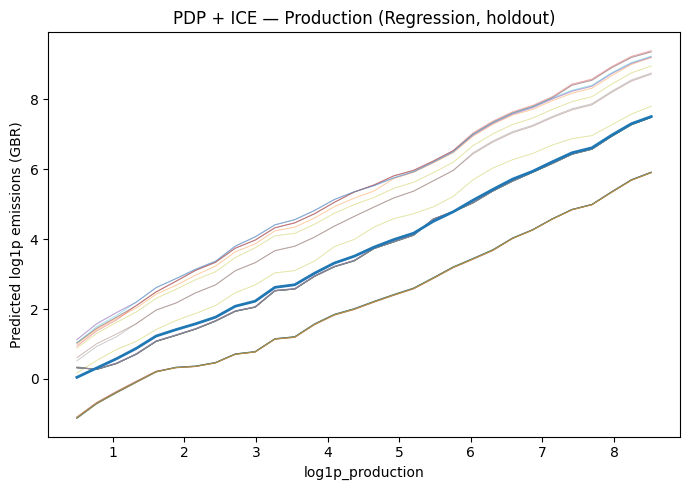

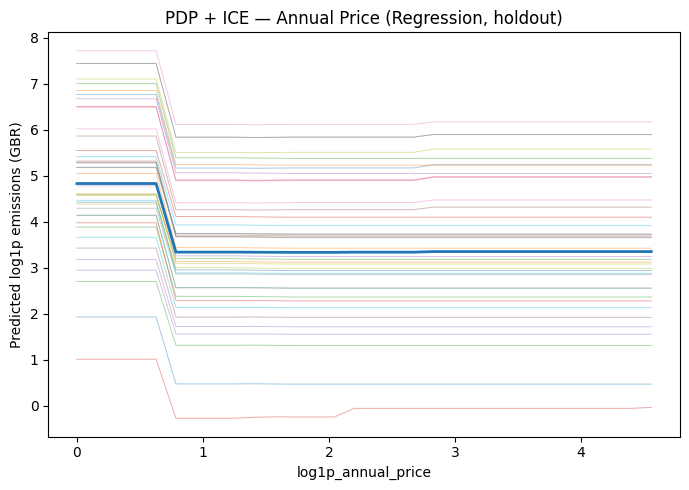

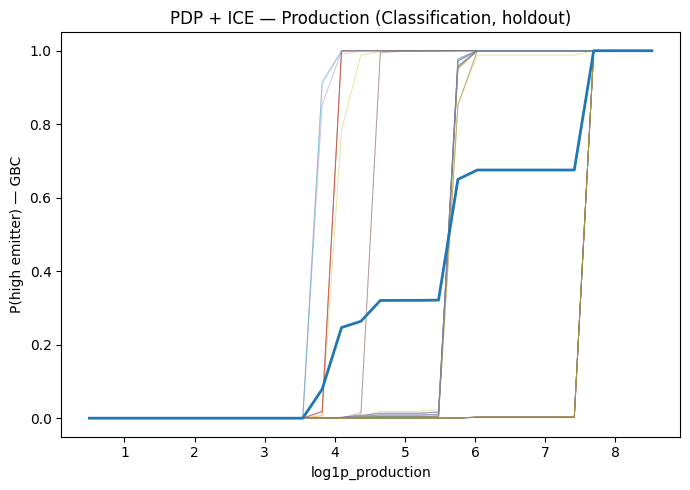

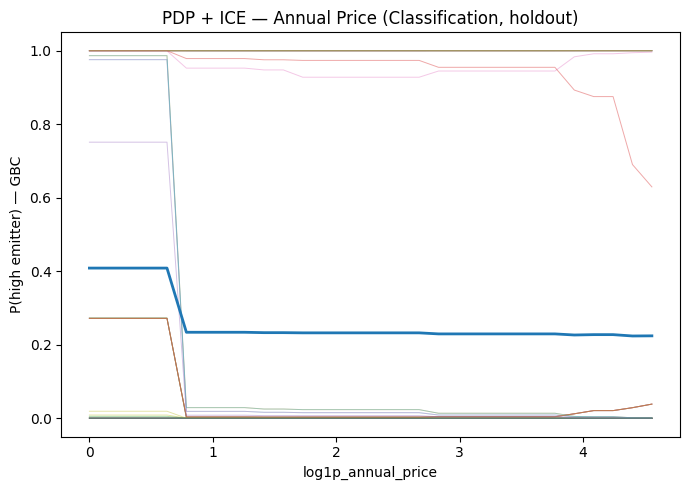

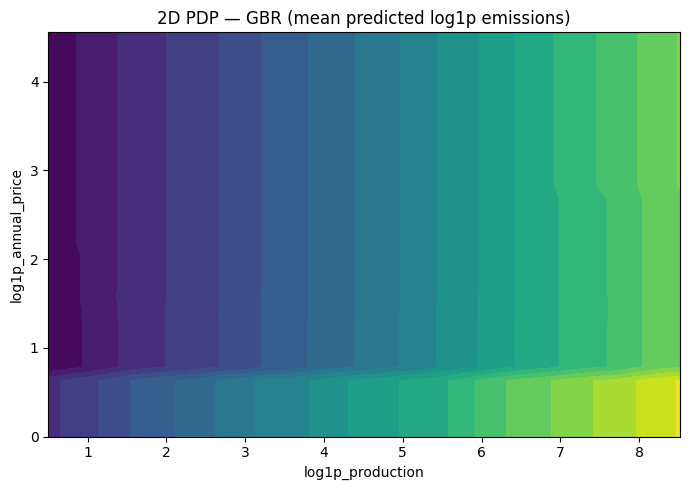

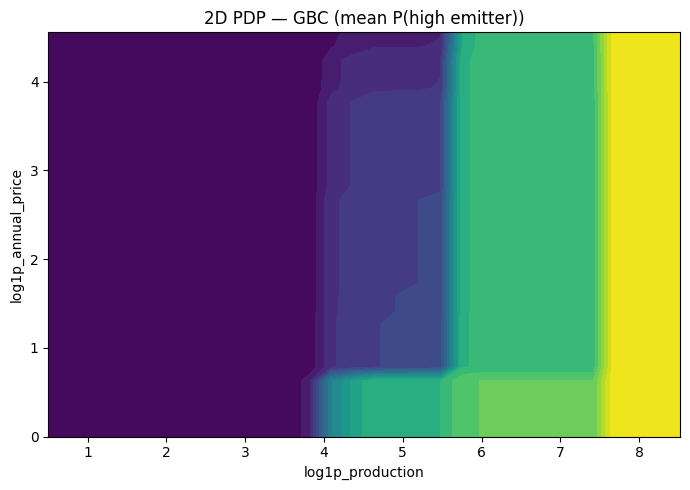

In [34]:
# Week 9 — Interpretability (PDP, ICE, 2D PDP) for Gradient Boosting

import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

# -------------------- Load features --------------------
FEAT = Path("week5_features.csv")
df = pd.read_csv(FEAT)

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

# OHE that works across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

prep = ColumnTransformer([("cat", ohe, cat_cols)], remainder="passthrough")

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

# Temporal split (≤2018 train, 2019–2022 test)
mask = df["year"] <= 2018
X_tr, X_te = X[mask], X[~mask]
y_tr_r, y_te_r = y_reg[mask], y_reg[~mask]
y_tr_c, y_te_c = y_clf[mask], y_clf[~mask]

# -------------------- Fit Week 7 best models --------------------
gbr = Pipeline([("prep", prep), ("m", GradientBoostingRegressor(
    n_estimators=400, learning_rate=0.1, max_depth=2,
    subsample=0.8, min_samples_leaf=1, random_state=42
))])

gbc = Pipeline([("prep", prep), ("m", GradientBoostingClassifier(
    n_estimators=600, learning_rate=0.1, max_depth=2,
    subsample=0.8, min_samples_leaf=5, random_state=42
))])

gbr.fit(X_tr, y_tr_r)
gbc.fit(X_tr, y_tr_c)

# -------------------- PDP / ICE helpers --------------------
def make_grid(series, n=30, q_low=0.01, q_high=0.99):
    lo = float(series.quantile(q_low)); hi = float(series.quantile(q_high))
    if not np.isfinite(lo): lo = float(series.min())
    if not np.isfinite(hi): hi = float(series.max())
    return np.linspace(lo, hi, n)

def pdp_1d(model, X_base, feature, grid, task):
    Xtmp = X_base.copy()
    vals = []
    for v in grid:
        Xtmp[feature] = v
        if task == "reg":
            pred = model.predict(Xtmp)
        else:
            if hasattr(model.named_steps["m"], "predict_proba"):
                pred = model.predict_proba(Xtmp)[:, 1]
            else:
                dfsc = model.decision_function(Xtmp)
                pred = (dfsc - dfsc.min()) / (dfsc.ptp() + 1e-12)
        vals.append(np.mean(pred))
    return np.array(vals)

def ice_curves(model, X_base, feature, grid, task, n_samples=40, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X_base), size=min(n_samples, len(X_base)), replace=False)
    curves = []
    for i in idx:
        row = X_base.iloc[[i]].copy()
        ys = []
        for v in grid:
            row[feature] = v
            if task == "reg":
                y = model.predict(row)[0]
            else:
                if hasattr(model.named_steps["m"], "predict_proba"):
                    y = model.predict_proba(row)[:, 1][0]
                else:
                    dfsc = model.decision_function(row)
                    dfsc = (dfsc - dfsc.min()) / (dfsc.ptp() + 1e-12)
                    y = dfsc[0]
            ys.append(y)
        curves.append(ys)
    return np.array(curves)

def pdp_2d(model, X_base, f1, f2, g1, g2, task):
    Z = np.zeros((len(g2), len(g1)))
    Xtmp = X_base.copy()
    for i, v1 in enumerate(g1):
        Xtmp[f1] = v1
        for j, v2 in enumerate(g2):
            Xtmp[f2] = v2
            if task == "reg":
                pred = model.predict(Xtmp)
            else:
                if hasattr(model.named_steps["m"], "predict_proba"):
                    pred = model.predict_proba(Xtmp)[:, 1]
                else:
                    dfsc = model.decision_function(Xtmp)
                    pred = (dfsc - dfsc.min()) / (dfsc.ptp() + 1e-12)
            Z[j, i] = np.mean(pred)
    return Z  # shape (len(g2), len(g1))

# -------------------- Targets & grids --------------------
feat_prod  = "log1p_production"
feat_price = "log1p_annual_price"
grid_prod  = make_grid(X_te[feat_prod], n=30)
grid_price = make_grid(X_te[feat_price], n=30)

# -------------------- Regression plots --------------------
pdp_prod_reg = pdp_1d(gbr, X_te, feat_prod, grid_prod, task="reg")
ice_prod_reg = ice_curves(gbr, X_te, feat_prod, grid_prod, task="reg")

plt.figure(figsize=(7,5))
for curve in ice_prod_reg:
    plt.plot(grid_prod, curve, linewidth=0.7, alpha=0.4)
plt.plot(grid_prod, pdp_prod_reg, linewidth=2.0)
plt.xlabel("log1p_production"); plt.ylabel("Predicted log1p emissions (GBR)")
plt.title("PDP + ICE — Production (Regression, holdout)")
plt.tight_layout(); plt.show()

pdp_price_reg = pdp_1d(gbr, X_te, feat_price, grid_price, task="reg")
ice_price_reg = ice_curves(gbr, X_te, feat_price, grid_price, task="reg")

plt.figure(figsize=(7,5))
for curve in ice_price_reg:
    plt.plot(grid_price, curve, linewidth=0.7, alpha=0.4)
plt.plot(grid_price, pdp_price_reg, linewidth=2.0)
plt.xlabel("log1p_annual_price"); plt.ylabel("Predicted log1p emissions (GBR)")
plt.title("PDP + ICE — Annual Price (Regression, holdout)")
plt.tight_layout(); plt.show()

# -------------------- Classification plots --------------------
pdp_prod_clf = pdp_1d(gbc, X_te, feat_prod, grid_prod, task="clf")
ice_prod_clf = ice_curves(gbc, X_te, feat_prod, grid_prod, task="clf")

plt.figure(figsize=(7,5))
for curve in ice_prod_clf:
    plt.plot(grid_prod, curve, linewidth=0.7, alpha=0.4)
plt.plot(grid_prod, pdp_prod_clf, linewidth=2.0)
plt.xlabel("log1p_production"); plt.ylabel("P(high emitter) — GBC")
plt.title("PDP + ICE — Production (Classification, holdout)")
plt.tight_layout(); plt.show()

pdp_price_clf = pdp_1d(gbc, X_te, feat_price, grid_price, task="clf")
ice_price_clf = ice_curves(gbc, X_te, feat_price, grid_price, task="clf")

plt.figure(figsize=(7,5))
for curve in ice_price_clf:
    plt.plot(grid_price, curve, linewidth=0.7, alpha=0.4)
plt.plot(grid_price, pdp_price_clf, linewidth=2.0)
plt.xlabel("log1p_annual_price"); plt.ylabel("P(high emitter) — GBC")
plt.title("PDP + ICE — Annual Price (Classification, holdout)")
plt.tight_layout(); plt.show()

# -------------------- 2D interaction surfaces --------------------
Z_reg = pdp_2d(gbr, X_te, feat_prod, feat_price, grid_prod, grid_price, task="reg")
plt.figure(figsize=(7,5))
plt.contourf(grid_prod, grid_price, Z_reg, levels=20)
plt.xlabel("log1p_production"); plt.ylabel("log1p_annual_price")
plt.title("2D PDP — GBR (mean predicted log1p emissions)")
plt.tight_layout(); plt.show()

Z_clf = pdp_2d(gbc, X_te, feat_prod, feat_price, grid_prod, grid_price, task="clf")
plt.figure(figsize=(7,5))
plt.contourf(grid_prod, grid_price, Z_clf, levels=20)
plt.xlabel("log1p_production"); plt.ylabel("log1p_annual_price")
plt.title("2D PDP — GBC (mean P(high emitter))")
plt.tight_layout(); plt.show()


I added interpretability on top of Week 7’s gradient boosting models. Using the same 2010–2022 features and the ≤2018 → 2019–2022 split, we trained GBR (regression) and GBC (classification) with the best Week 7 settings. We then generated PDP + ICE for two levers: log1p_production and log1p_annual_price, and built 2D partial-dependence surfaces (production × price) for both tasks.

Findings were consistent and simple. Production shows a near-monotone, almost linear rise in predicted log-emissions (GBR). In classification, P(high emitter) stays low at small production, then rises sharply once log1p_production crosses a mid-range threshold. Price is a weak, secondary signal: shallow slope, small shifts at low values, then a plateau. The 2D surfaces are dominated by the production axis; price nudges the surface but does not reshape it. This pattern matches Weeks 5–8: emissions scale with output; commodity/price fine-tune the level; incident features contribute little at annual granularity.

Implication: the system is largely additive and near-linear in production, with limited higher-order interactions. That explains why linear baselines perform well, while trees/boosting pick up small nonlinear edges.